# Ex.No.9 - Depth Estimation

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 14/03/2026_

In [34]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

In [42]:
def load_custom_images(left_path, right_path):
    # Load grayscale stereo images
    print(f"Loading left image: {left_path}")
    print(f"Loading right image: {right_path}\n")

    left_img = cv2.imread(left_path)
    right_img = cv2.imread(right_path)

    if left_img is None or right_img is None:
        print("Error: Could not load images!")
        return None, None

    # Convert to grayscale
    left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
    right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)
    
    print(f"Left gray image size: {left_gray.shape}")
    print(f"Right gray image size: {right_gray.shape}\n")

    return left_gray, right_gray

In [36]:
def generate_stereo_images():
    print("Generating synthetic stereo images...\n")

    height, width = 480, 640
    left_img = np.ones((height, width), dtype=np.uint8) * 150  # Base image

    square_size = 40
    # Checkerboard background
    for i in range(0, height, square_size):
        for j in range(0, width, square_size):
            if (i // square_size + j // square_size) % 2 == 0:
                left_img[i:i+square_size, j:j+square_size] = 100

    # Add objects (different depths)
    cv2.circle(left_img, (150, 150), 60, 255, -1)
    cv2.circle(left_img, (200, 150), 10, 50, -1)

    cv2.rectangle(left_img, (380, 200), (520, 320), 220, -1)
    cv2.rectangle(left_img, (390, 210), (510, 310), 180, 2)

    pts = np.array([[520, 80], [620, 80], [570, 200]], np.int32)
    cv2.polylines(left_img, [pts], True, 100, 2)
    cv2.fillPoly(left_img, [pts], 120)

    cv2.circle(left_img, (100, 350), 40, 200, -1)
    cv2.circle(left_img, (300, 400), 35, 180, -1)
    cv2.circle(left_img, (500, 380), 30, 160, -1)

    cv2.putText(left_img, "STEREO TEST IMAGE", (150, 460),
                cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 2)

    # Right image with shifts (disparity)
    right_img = np.ones((height, width), dtype=np.uint8) * 150

    for i in range(0, height, square_size):
        for j in range(0, width, square_size):
            if (i // square_size + j // square_size) % 2 == 0:
                right_img[i:i+square_size, j:j+square_size] = 100

    cv2.circle(right_img, (130, 150), 60, 255, -1)
    cv2.circle(right_img, (180, 150), 10, 50, -1)

    cv2.rectangle(right_img, (368, 200), (508, 320), 220, -1)
    cv2.rectangle(right_img, (378, 210), (498, 310), 180, 2)

    pts_right = np.array([[515, 80], [615, 80], [565, 200]], np.int32)
    cv2.polylines(right_img, [pts_right], True, 100, 2)
    cv2.fillPoly(right_img, [pts_right], 120)

    cv2.circle(right_img, (82, 350), 40, 200, -1)
    cv2.circle(right_img, (286, 400), 35, 180, -1)
    cv2.circle(right_img, (492, 380), 30, 160, -1)

    cv2.putText(right_img, "STEREO TEST IMAGE", (135, 460),
                cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 2)

    print("Synthetic stereo images generated!\n")
    return left_img, right_img

In [37]:
def compute_depth(left_img, right_img):
    print("Computing disparity and depth maps...")

    # Stereo matching
    stereo = cv2.StereoBM_create(numDisparities=16*5, blockSize=15)

    # Improve matching quality
    stereo.setPreFilterType(1)
    stereo.setPreFilterSize(7)
    stereo.setPreFilterCap(63)
    stereo.setTextureThreshold(10)
    stereo.setUniquenessRatio(15)
    stereo.setSpeckleRange(32)
    stereo.setSpeckleWindowSize(100)

    # Resize if too large (faster processing)
    h, w = left_img.shape
    if w > 800:
        scale = 800 / w
        left_img = cv2.resize(left_img, None, fx=scale, fy=scale)
        right_img = cv2.resize(right_img, None, fx=scale, fy=scale)
        print("Images resized:", left_img.shape)
        
    disparity = stereo.compute(left_img, right_img)

    # Depth formula
    baseline = 120
    focal_length = 400

    disparity = np.float32(disparity)
    disparity[disparity <= 0] = 0.1  # Avoid division by zero

    depth = (baseline * focal_length) / (disparity + 1e-5)

    print("Depth computation complete!\n")
    return disparity, depth

In [45]:
def visualize_all(left_img, right_img, disparity, depth):
    # Apply bilateral filter
    depth = cv2.bilateralFilter(depth.astype(np.float32), 9, 75, 75)
    
    # Remove outliers
    valid = depth[depth > 0]
    if len(valid) > 0:
        median = np.median(valid)
        depth[depth > median * 3] = 0
        depth[depth < median * 0.1] = 0
    
    # Normalize for display
    disparity_norm = cv2.normalize(disparity, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
    depth_norm = cv2.normalize(depth, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
    depth_colored = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Stereo Vision: Disparity and Depth Estimation")

    axes[0, 0].imshow(left_img, cmap='gray')
    axes[0, 0].set_title('Left Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(right_img, cmap='gray')
    axes[0, 1].set_title('Right Image')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(disparity_norm, cmap='gray')
    axes[1, 0].set_title('Disparity Map')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(cv2.cvtColor(depth_colored, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Depth Map')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Depth statistics
    valid_depth = depth[depth > 0]

    print("Depth Statistics")
    if len(valid_depth) > 0:
        print("Min:", np.min(valid_depth))
        print("Max:", np.max(valid_depth))
        print("Mean:", np.mean(valid_depth))
        print("Median:", np.median(valid_depth))
        print("Std:", np.std(valid_depth))
    else:
        print("No valid depth values")

In [39]:
def main(use_custom=False, name = "syn", left_path=None, right_path=None):
    # Load or generate images
    if use_custom and left_path and right_path:
        left_img, right_img = load_custom_images(left_path, right_path)
        if left_img is None:
            print("Falling back to synthetic...\n")
            left_img, right_img = generate_stereo_images()
    else:
        left_img, right_img = generate_stereo_images()

    if left_img.shape != right_img.shape:
        print("Resizing images to match...")
        right_img = cv2.resize(right_img, (left_img.shape[1], left_img.shape[0]))

    # Save input images
    cv2.imwrite(rf"D:\VI\IP & CV\Lab Experiments\Inputs\{name}_left.png", left_img)
    cv2.imwrite(rf"D:\VI\IP & CV\Lab Experiments\Inputs\{name}_right.png", right_img)

    print("Images saved\n")

    # Compute depth
    disparity, depth = compute_depth(left_img, right_img)

    # Visualize results
    visualize_all(left_img, right_img, disparity, depth)

    # Save output maps
    disp_norm = cv2.normalize(disparity, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
    depth_norm = cv2.normalize(depth, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
    depth_color = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)

    cv2.imwrite(rf"D:\VI\IP & CV\Lab Experiments\Outputs\{name}_disparity_map.jpg", disp_norm)
    cv2.imwrite(rf"D:\VI\IP & CV\Lab Experiments\Outputs\{name}_depth_map.jpg", depth_color)

    print("Output saved")
    print("Complete")

1. Using Synthetic Images

Generating synthetic stereo images...

Synthetic stereo images generated!

Images saved

Computing disparity and depth maps...
Depth computation complete!



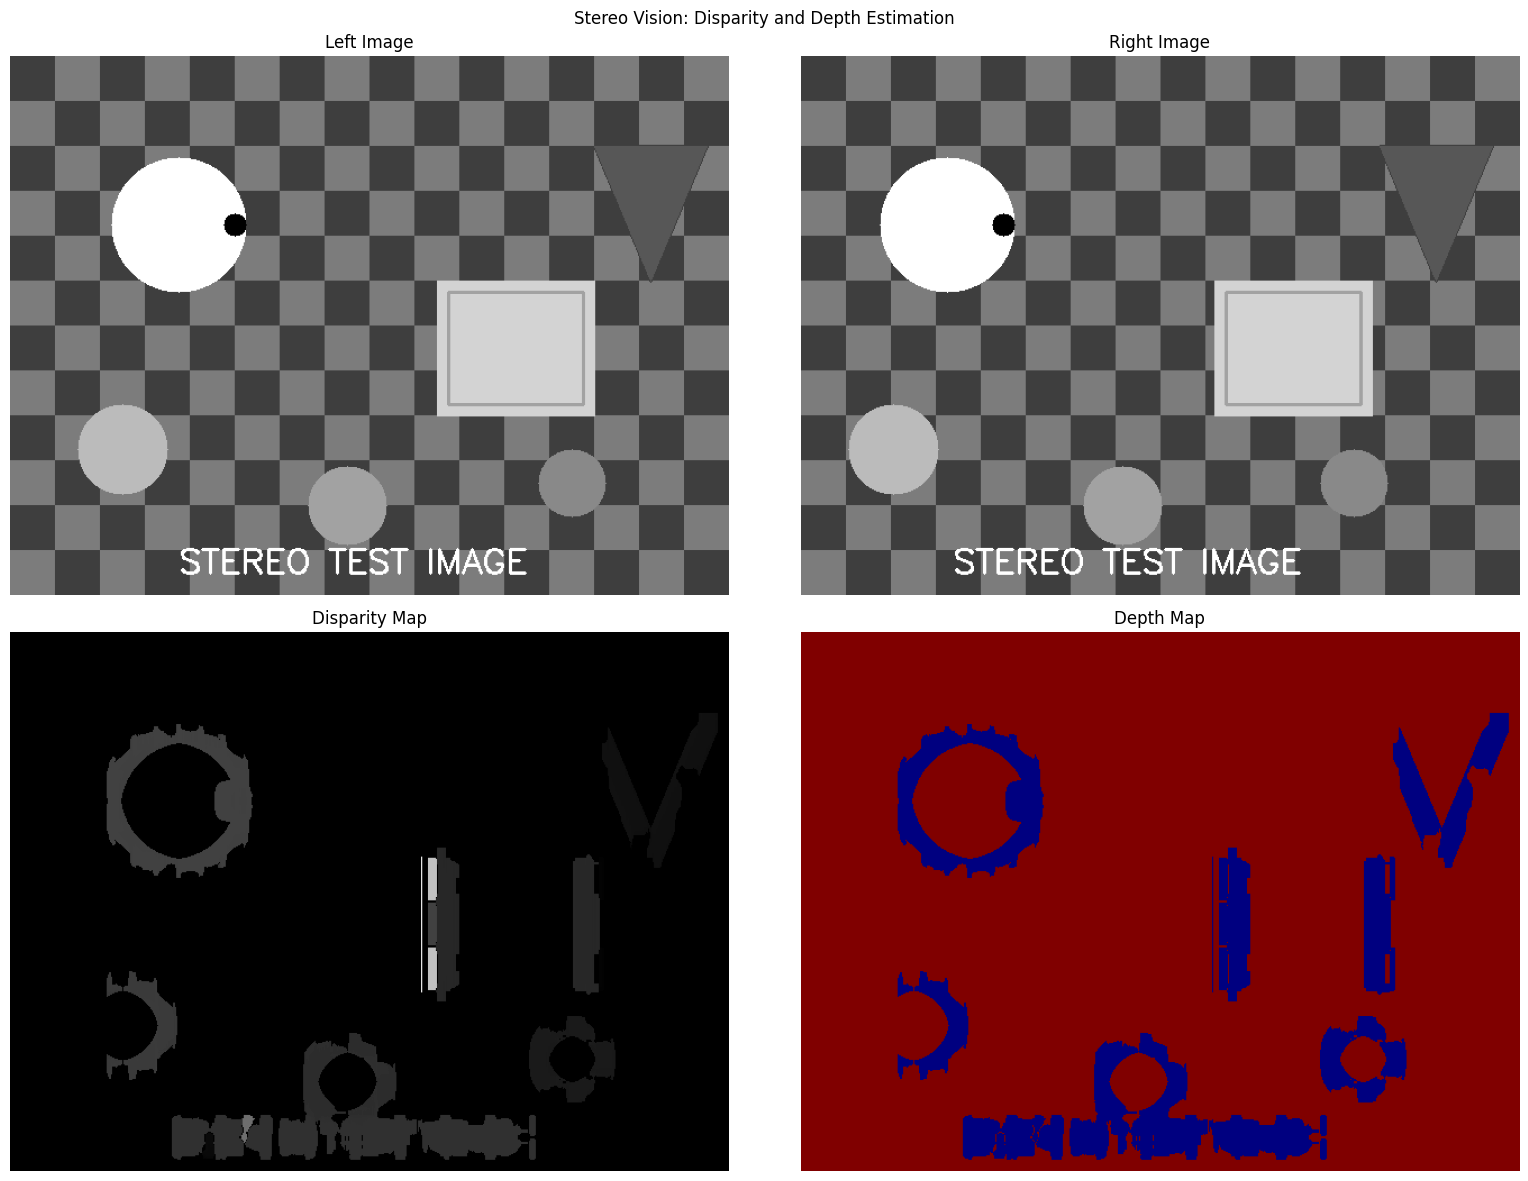

Depth Statistics
Min: 479951.8
Max: 479952.28
Mean: 479952.0
Median: 479951.94
Std: 0.06371295
Output saved
Complete


In [40]:
print("1. Using Synthetic Images\n")
main(use_custom=False)

Loading left image: D:\VI\IP & CV\Lab Experiments\Inputs\left_view.png
Loading right image: D:\VI\IP & CV\Lab Experiments\Inputs\right_view.png

Left gray image size: (298, 397)
Right gray image size: (298, 397)

Images saved

Computing disparity and depth maps...
Depth computation complete!



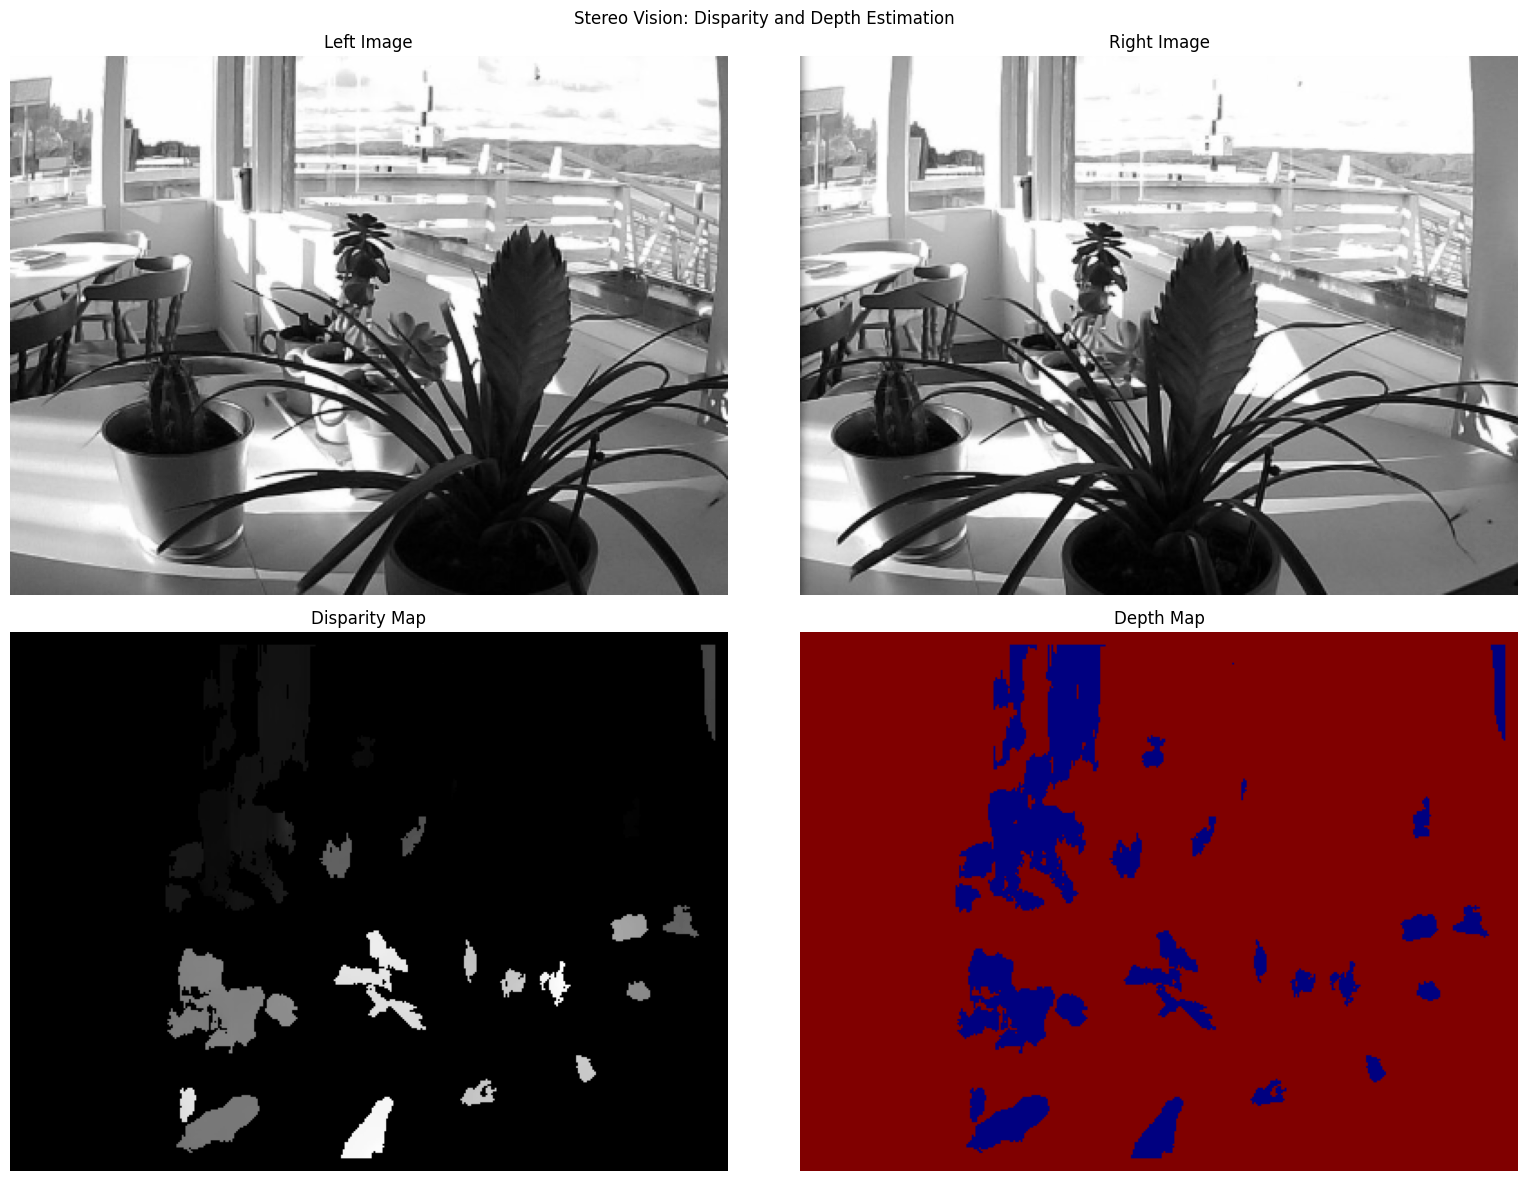

Depth Statistics
Min: 479951.8
Max: 479952.25
Mean: 479952.03
Median: 479951.94
Std: 0.092534475
Output saved
Complete


In [46]:
# Custom images
main(True,"plant",
     r"D:\VI\IP & CV\Lab Experiments\Inputs\left_view.png",
     r"D:\VI\IP & CV\Lab Experiments\Inputs\right_view.png")

### Applying Preprocessing using Histogram Equalization and enhancing depth

In [56]:
def load_stereo_images(left_path, right_path):
    print(f"Loading left image: {left_path}")
    print(f"Loading right image: {right_path}\n")

    left_img = cv2.imread(left_path)
    right_img = cv2.imread(right_path)

    if left_img is None:
        print(f"❌ Error: Could not load left image!")
        return None, None

    if right_img is None:
        print(f"❌ Error: Could not load right image!")
        return None, None

    print(f"✓ Left image size: {left_img.shape}")
    print(f"✓ Right image size: {right_img.shape}\n")

    return left_img, right_img

In [57]:
def preprocess_images(left_img, right_img):
    print("Preprocessing images...")

    left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
    right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

    if left_gray.shape != right_gray.shape:
        print(f"⚠️ Images have different sizes!")
        h = min(left_gray.shape[0], right_gray.shape[0])
        w = min(left_gray.shape[1], right_gray.shape[1])
        left_gray = left_gray[:h, :w]
        right_gray = right_gray[:h, :w]
        left_img = left_img[:h, :w]
        right_img = right_img[:h, :w]
        print(f"Resized to: {left_gray.shape}\n")

    h, w = left_gray.shape
    if w > 1000:
        scale = 1000 / w
        left_gray = cv2.resize(left_gray, None, fx=scale, fy=scale)
        right_gray = cv2.resize(right_gray, None, fx=scale, fy=scale)
        left_img = cv2.resize(left_img, None, fx=scale, fy=scale)
        right_img = cv2.resize(right_img, None, fx=scale, fy=scale)
        print(f"Resized for processing: {left_gray.shape}\n")

    left_gray = cv2.equalizeHist(left_gray)
    right_gray = cv2.equalizeHist(right_gray)

    print("✓ Preprocessing complete!\n")

    return left_img, right_img, left_gray, right_gray

In [58]:
def compute_depth_stereobm(left_gray, right_gray):
    print("Computing disparity using StereoBM...")

    stereo = cv2.StereoBM_create(numDisparities=128, blockSize=15)

    stereo.setPreFilterType(1)
    stereo.setPreFilterSize(5)
    stereo.setPreFilterCap(61)
    stereo.setTextureThreshold(507)
    stereo.setUniquenessRatio(15)
    stereo.setSpeckleRange(32)
    stereo.setSpeckleWindowSize(100)
    stereo.setMinDisparity(0)

    disparity = stereo.compute(left_gray, right_gray)

    print("✓ Disparity computed!\n")

    return disparity

In [59]:
def compute_depth_from_disparity(disparity):
    print("Converting disparity to depth...")

    baseline = 65.0
    focal_length = 1000.0

    disparity_float = np.float32(disparity) / 16.0

    print(f"Disparity range: {np.min(disparity_float):.2f} to {np.max(disparity_float):.2f}")

    disparity_float[disparity_float <= 0] = 0.1

    depth = (baseline * focal_length) / disparity_float

    depth[depth > 10000] = 0

    print("✓ Depth map calculated!\n")

    return disparity_float, depth

In [60]:
def apply_filters(depth):
    print("Applying filters to improve depth map...")

    depth_filtered = cv2.bilateralFilter(depth.astype(np.float32), 9, 75, 75)
    depth_filtered = cv2.medianBlur(depth_filtered, 5)

    valid_pixels = depth_filtered[depth_filtered > 0]

    if len(valid_pixels) > 0:
        median = np.median(valid_pixels)
        mad = np.median(np.abs(valid_pixels - median))

        lower_bound = median - 2.5 * mad
        upper_bound = median + 2.5 * mad

        depth_filtered[(depth_filtered < lower_bound) | (depth_filtered > upper_bound)] = 0

    print("✓ Filters applied!\n")

    return depth_filtered

In [61]:
def visualize_results(left_img, right_img, disparity, depth):

    disparity_norm = cv2.normalize(disparity, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
    depth_norm = cv2.normalize(depth, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)

    depth_colored = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("Stereo Vision - Depth Estimation Results")

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB))
    plt.title('Left Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB))
    plt.title('Right Image')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(disparity_norm, cmap='gray')
    plt.title('Disparity Map')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(depth_colored, cv2.COLOR_BGR2RGB))
    plt.title('Depth Map')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [62]:
def print_statistics(disparity, depth):
    print("\n" + "="*70)
    print("DEPTH ESTIMATION STATISTICS")
    print("="*70)

    valid_disparity = disparity[disparity > 0]
    valid_depth = depth[depth > 0]

    print("\nDisparity Statistics:")
    print(f" Min: {np.min(valid_disparity):.2f}")
    print(f" Max: {np.max(valid_disparity):.2f}")
    print(f" Mean: {np.mean(valid_disparity):.2f}")
    print(f" Std: {np.std(valid_disparity):.2f}")

    print("\nDepth Statistics:")
    print(f" Min: {np.min(valid_depth):.2f}")
    print(f" Max: {np.max(valid_depth):.2f}")
    print(f" Mean: {np.mean(valid_depth):.2f}")
    print(f" Median: {np.median(valid_depth):.2f}")
    print(f" Std: {np.std(valid_depth):.2f}")

    total = disparity.size
    valid = len(valid_depth)

    print(f"\nValid Pixels: {valid}/{total} ({valid/total*100:.1f}%)")
    print("="*70 + "\n")

In [63]:
def main(name):
    print("STEREO VISION - DEPTH ESTIMATION\n")

    left_img, right_img = load_stereo_images(
        r"D:\VI\IP & CV\Lab Experiments\Inputs\left_view.png",
        r"D:\VI\IP & CV\Lab Experiments\Inputs\right_view.png"
    )

    if left_img is None or right_img is None:
        print("Error loading images")
        return

    left_img, right_img, left_gray, right_gray = preprocess_images(left_img, right_img)

    disparity = compute_depth_stereobm(left_gray, right_gray)

    disparity_float, depth = compute_depth_from_disparity(disparity)

    depth_filtered = apply_filters(depth)

    print_statistics(disparity_float, depth_filtered)

    visualize_results(left_img, right_img, disparity_float, depth_filtered)

    disp_norm = cv2.normalize(disparity_float, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
    depth_norm = cv2.normalize(depth_filtered, None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)

    depth_colored = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)

    cv2.imwrite(rf"D:\VI\IP & CV\Lab Experiments\Outputs\{name}_disparity_map.jpg", disp_norm)
    cv2.imwrite(rf"D:\VI\IP & CV\Lab Experiments\Outputs\{name}_depth_map.jpg", depth_colored)

    print("Results saved")

STEREO VISION - DEPTH ESTIMATION

Loading left image: D:\VI\IP & CV\Lab Experiments\Inputs\left_view.png
Loading right image: D:\VI\IP & CV\Lab Experiments\Inputs\right_view.png

✓ Left image size: (298, 397, 3)
✓ Right image size: (298, 397, 3)

Preprocessing images...
✓ Preprocessing complete!

Computing disparity using StereoBM...
✓ Disparity computed!

Converting disparity to depth...
Disparity range: -1.00 to 92.31
✓ Depth map calculated!

Applying filters to improve depth map...
✓ Filters applied!


DEPTH ESTIMATION STATISTICS

Disparity Statistics:
 Min: 0.10
 Max: 92.31
 Mean: 1.83
 Std: 10.53

Depth Statistics:
 Min: 710.59
 Max: 1531.05
 Mean: 936.62
 Median: 866.94
 Std: 219.85

Valid Pixels: 2273/118306 (1.9%)



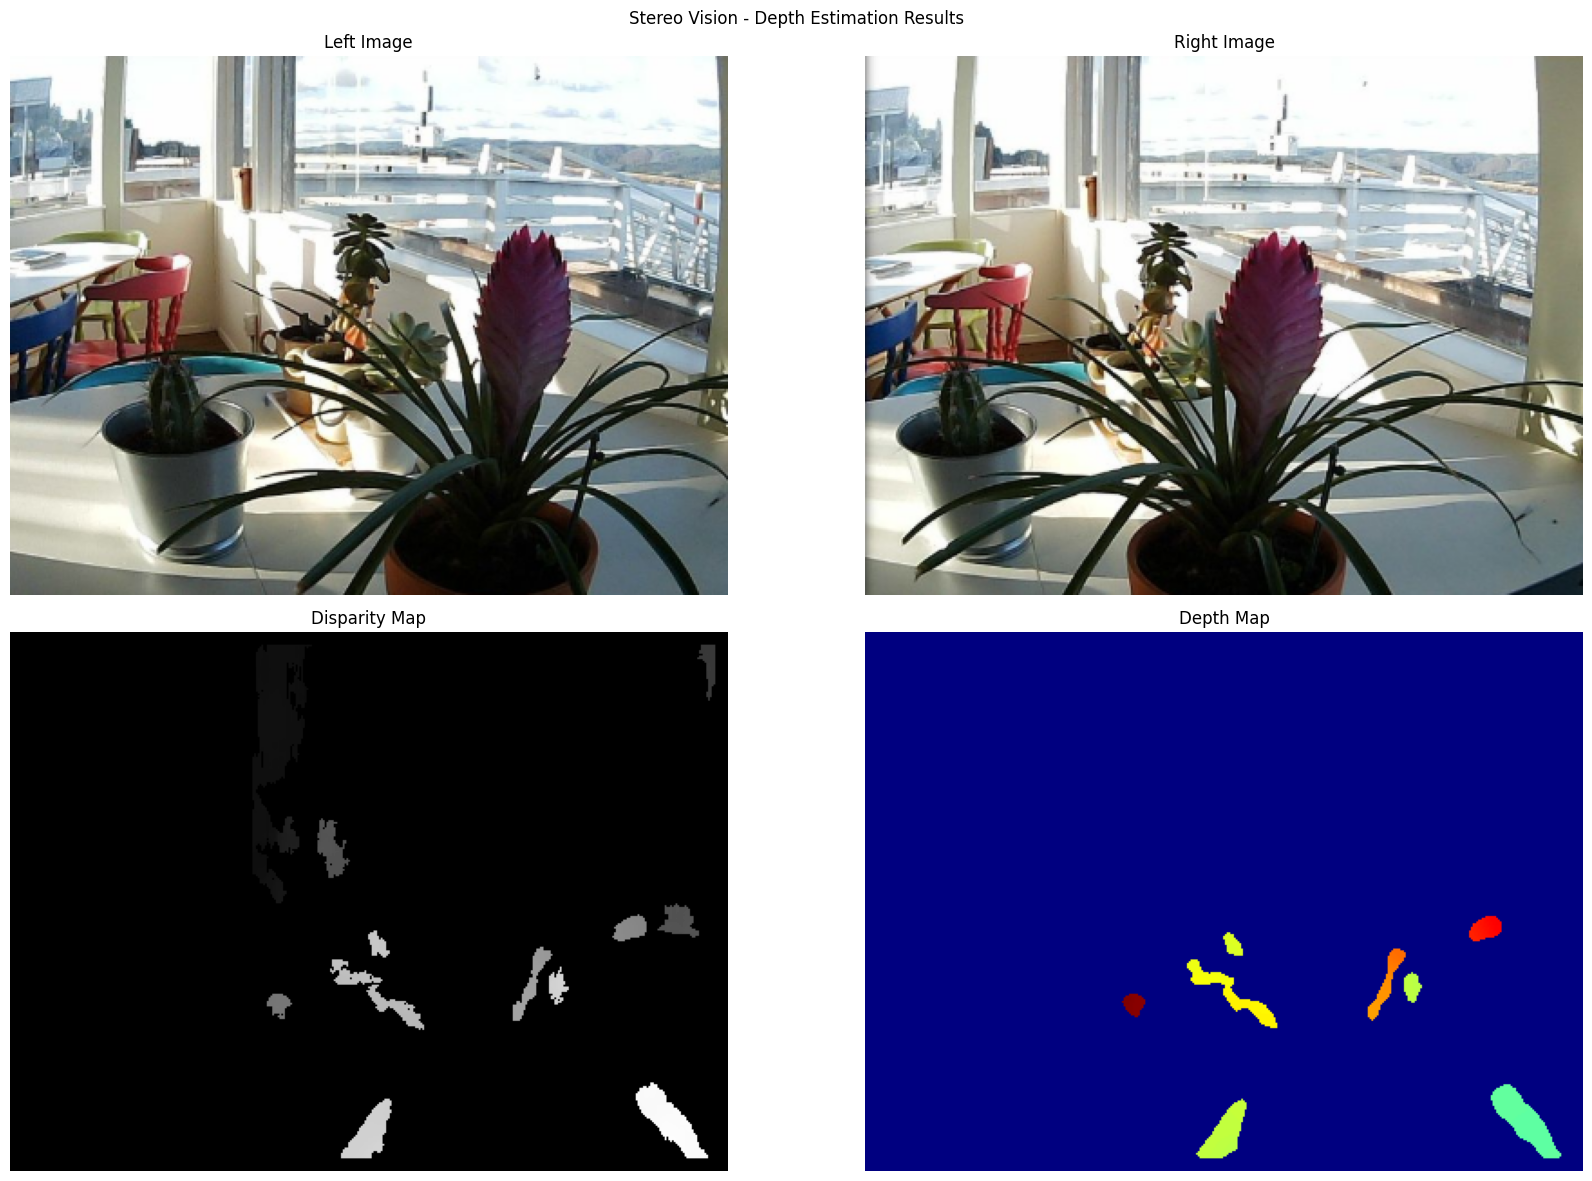

Results saved


In [64]:
if __name__ == "__main__":
    main("plant")